# PIECEWISE PREDICTIONS

This notebook explores the effect of oscillating species on the accuracy of a linear approximation. The conclusion is that the effect is minimal.

In [1]:
import matplotlib.pyplot as plt  # type: ignore
import numpy as np  # type: ignore
import os
import pandas as pd  # type: ignore
from src.timecourse_iterator import TimecourseIterator # type: ignore
from typing import Optional, cast, List, Union

import src.constants as cn
from src.score import Score
from src.system_discovery import SystemDiscovery  # type: ignore
from src.piecewise_system_discovery import PiecewiseSystemDiscovery
from src.model import Model
from src.timecourse import Timecourse

# Helpers

## getSystemDF

In [2]:
def getSystemDF(df: pd.DataFrame, model_num: Optional[int]=None, is_species: bool = False) -> pd.DataFrame:
    if model_num is not None:
        model_name = Model.getBiomodelName(model_num)#
        dff = df [df[cn.COL_SYSTEM_ID] == model_name]
    else:
        dff = df.copy()
    if is_species:
        sel = dff[cn.COL_AGGREGATION_TYPE] != cn.COL_AGGREGATION_TYPE_MODEL
    else:
        sel = dff[cn.COL_AGGREGATION_TYPE] == cn.COL_AGGREGATION_TYPE_MODEL
    return dff[sel]

#getSystemDF(DF)

## getPredictionDF

In [59]:
def getPredictionDF(
        threshold: Optional[float] = None,        # coefficient threshold
        removal: Optional[int] = None,            # 0: don't remove changepoints; 1: remove changepoints
        maxreduction: Optional[float] = None,     # max_accuracy_reduction
        manycp: Optional[int] =  None,            # many changepoints if 1 else 0
        curated: int = 1,                         # filtering models by curation.csv if 1, else 0
        ) -> pd.DataFrame:
    # Loads the correct file and returns a it as a dataframe. Eliminates models from curation.csv.
    all_ffiles = [f for f in os.listdir(cn.DATA_DIR) if "piecewise_predictions__" in f]
    ffiles = all_ffiles.copy()
    #
    if threshold is not None:
        ffiles = [f for f in ffiles if f"threshold_{threshold}" in f]
    if removal is not None:
        ffiles = [f for f in ffiles if f"removal_{removal}" in f]
    if maxreduction is not None:
        ffiles = [f for f in ffiles if f"maxreduction_{maxreduction}" in f]
    if manycp is not None:
        ffiles = [f for f in ffiles if f"manycp_{manycp}" in f]
    # Analyze the files selected
    if len(ffiles) > 1:
        raise ValueError(f"Ambiguous request. Found {ffiles}")
    if len(ffiles) == 0:
        raise ValueError(f"No file found. Choices are: {all_ffiles}")
    # Exclude models that have been removed by curation
    curation_exclusions = pd.read_csv(cn.CURATION_PATH)[cn.COL_SYSTEM_ID].to_list()
    path = os.path.join(cn.DATA_DIR, ffiles[0])
    df = pd.read_csv(path)
    sel = ~df[cn.COL_SYSTEM_ID].isin(curation_exclusions)
    return df[sel]

# Tests
assert(len(getPredictionDF(maxreduction=0.05, threshold=0.001)) > 0)
try:
    # No file found
    _ = getPredictionDF(num_point=1)
    raise ValueError("Should fail this test")
except Exception as e:
    #print(e)
    pass
try:
    # Many files found
    _ = getPredictionDF()
    #raise ValueError("Should fail this test")
except Exception as e:
    #print(e)
    pass
print("OK!")
    

OK!


# Initializations

In [4]:
# Non-oscillating species timecourses
path = os.path.join(cn.DATA_DIR, f"find_oscillating_models.csv")
NONOSCILLATION_DF = pd.read_csv(path)
NONOSCILLATION_DF = NONOSCILLATION_DF [NONOSCILLATION_DF[cn.COL_FREQUENCIES] == "[]"]
NONOSCILLATION_DF = NONOSCILLATION_DF [NONOSCILLATION_DF[cn.COL_SPECIES_NAME] != cn.COL_AGGREGATION_TYPE_MODEL]
NONOSCILLATION_DF["key"] = [m + "_" + str(s) for m, s in zip(NONOSCILLATION_DF[cn.COL_SYSTEM_ID], NONOSCILLATION_DF[cn.COL_SPECIES_NAME])]
NONOSCILLATION_DF

,system_id,species_name,frequencies,endtime,key
17,BIOMD0000000042,GLC,[],300.0,BIOMD0000000042_GLC
19,BIOMD0000000042,FBP,[],300.0,BIOMD0000000042_FBP
20,BIOMD0000000042,GAP,[],300.0,BIOMD0000000042_GAP
21,BIOMD0000000042,NAD,[],300.0,BIOMD0000000042_NAD
22,BIOMD0000000042,NADH,[],300.0,BIOMD0000000042_NADH
...,...,...,...,...,...
4552,BIOMD0000001059,sursmac,[],7000.0,BIOMD0000001059_sursmac
4553,BIOMD0000001059,smacmit,[],7000.0,BIOMD0000001059_smacmit
4554,BIOMD0000001059,smac,[],7000.0,BIOMD0000001059_smac
4555,BIOMD0000001060,x1,[],40.0,BIOMD0000001060_x1


# Individual models

/Users/jlheller/home/Technical/repos/linearity_analysis/src/scaler.py:89: RuntimeWarning: overflow encountered in multiply
  denormalized_arr = normalized_arr * self._scale_arr
/Users/jlheller/home/Technical/repos/linearity_analysis/src/scaler.py:89: RuntimeWarning: overflow encountered in multiply
  denormalized_arr = normalized_arr * self._scale_arr
/Users/jlheller/home/Technical/repos/linearity_analysis/mla/lib/python3.11/site-packages/matplotlib/axes/_base.py:3067: RuntimeWarning: overflow encountered in scalar subtract
  delta = (x1t - x0t) * margin


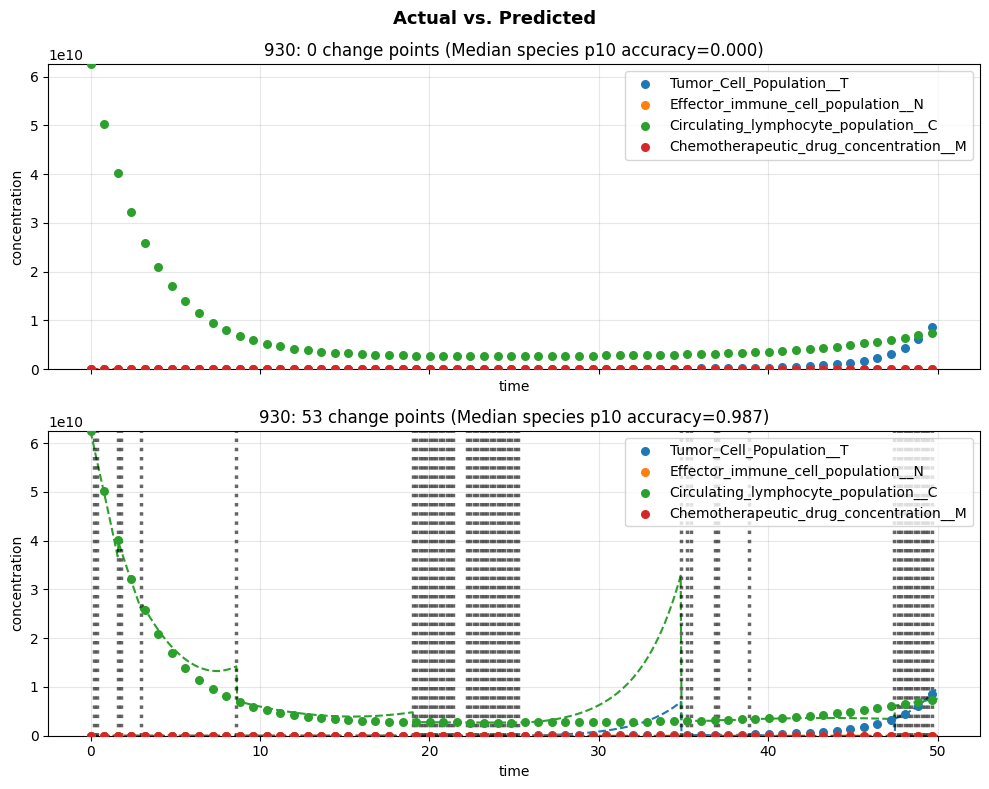

<Figure size 640x480 with 0 Axes>

In [40]:
#for model_num in [45, 278, 548, 551, 1045, 5, 42, 930]:
models = [930]
for model_num in models:
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, num_point =1000)
    df = timecourse.timecourse_df
    try:
        for changepoint_idx, max_changepoint in enumerate([5000]):
            for is_changepoint_removal in [True]:
                psd = PiecewiseSystemDiscovery(df, 
                                               #changepoints=specified_changepoints,
                                               max_changepoint=max_changepoint,
                                               is_changepoint_removal=is_changepoint_removal,
                                                max_fractional_reduction=0.05 , model_name=str(model_num))
                psd.fit()
                if changepoint_idx == 0:
                    result = psd.plotPiecewise(legend=False, num_true_point=60)
                else:
                    result = psd.plotPiecewise(legend=False, num_true_point=60, is_nochangepoint_plot=False)
                plt.figure()
    except Exception as e:
        print(f"Could not process {model_num}: {e}")

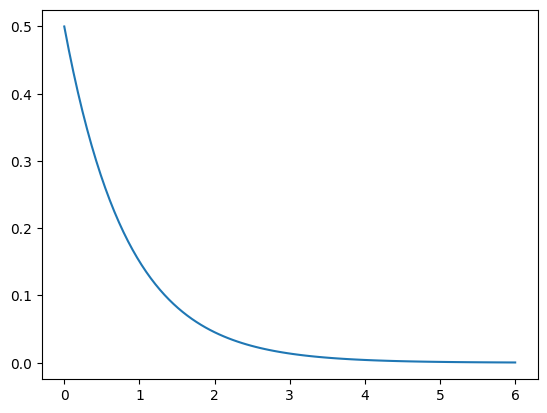

In [6]:
# Analysis of model 45. We can fit an exponential to Y or X
arr = np.linspace(0, 6, 100)
plt.plot(arr, 0.5*np.exp(-1.2*arr))

# Distribution of Number Species Across models

In [7]:
num_species_dct = {}
for item in TimecourseIterator():
    num_species_dct.update({item.model_name: len(item.timecourse.timecourse_df.columns)})
len(num_species_dct)

434

In [8]:
[m for m, s in num_species_dct.items() if s > 100]

['BIOMD0000000474', 'BIOMD0000000667']

Text(0.5, 1.0, 'Number Species per Model')

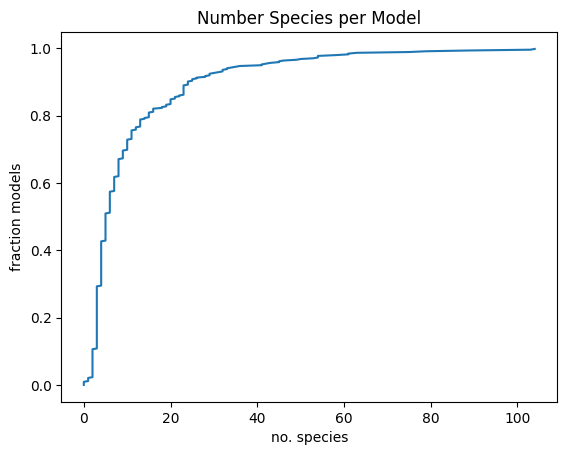

In [9]:
values = np.sort(list(num_species_dct.values()))
yv = np.array(range(len(values)))/len(values)
plt.plot(values, yv)
plt.xlabel("no. species")
plt.ylabel("fraction models")
plt.title("Number Species per Model")

Text(0.5, 1.0, 'CDF of Species by Model Size')

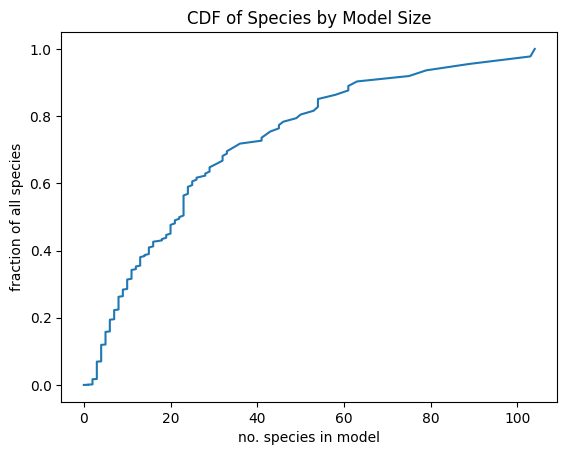

In [10]:
frac_species = np.cumsum(values)/np.sum(values)
_, ax = plt.subplots(1)
ax.plot(values, frac_species)
ax.set_xlabel("no. species in model")
ax.set_ylabel("fraction of all species")
ax.set_title("CDF of Species by Model Size")

# CDFs

## All Models

def getColumn(df: pd.DataFrame, col: str = "a80",  is_species: bool = True, max_changepoint: int = 10,
        is_oscillation: bool = True) -> pd.Series:
    if is_species:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] != cn.COL_AGGREGATION_TYPE_MODEL]
    else:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] == cn.COL_AGGREGATION_TYPE_MODEL]
    result_df = result_df[result_df[cn.COL_MAX_CHANGEPOINT] == max_changepoint]
    # Handle oscillations
    if not is_oscillation:
        pass
        
    return result_df[col]

# Tests
ser = getColumn(DF)
ser

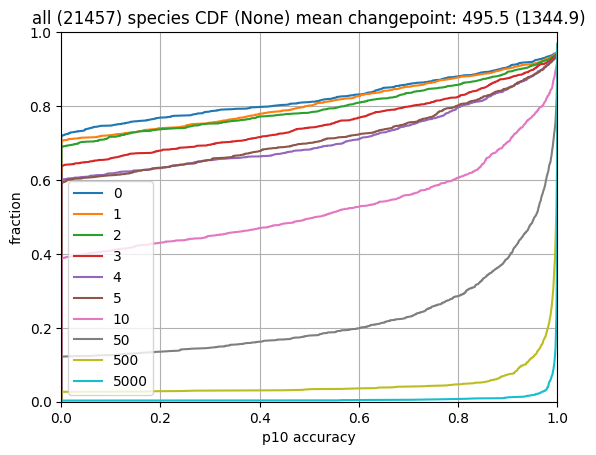

In [53]:
def plotCDF(coefficient_threshold: Optional[float] = None, 
            is_species: bool = True, 
            col="p10",
            is_non_oscillating: Optional[bool] = None,
            max_fractional_reduction: Optional[float] = None) -> pd.DataFrame:
    # Construct the dataframe to process
    if False:
        df = getPredictionDF(max_changepoint=max_changepoint, coefficient_threshold=coefficient_threshold,
            max_fractional_reduction=max_fractional_reduction)
    else:
        #path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{coefficient_threshold}_noremoval.csv")
        path = os.path.join(cn.DATA_DIR, f"piecewise_predictions.csv")
        df = pd.read_csv(path)
#    df["key"] = NONOSCILLATION_DF[cn.COL_SYSTEM_ID] + "_" + NONOSCILLATION_DF[cn.COL_SPECIES_NAME]
#    if is_non_oscillating is not None:
#        df["key"] = NONOSCILLATION_DF[cn.COL_SYSTEM_ID] + "_" + NONOSCILLATION_DF[cn.COL_SPECIES_NAME]
#        #
#        sel = df["key"].isin(NONOSCILLATION_DF["key"].unique())
#        if is_non_oscillating:
#            df = df[sel]
#        else:
#            df = df[~sel]
    #
    obs_max_changepoints = df["max_changepoint"].unique()
    dct = {c: getColumn(df, col=col, max_changepoint = c, is_species=is_species) for c in obs_max_changepoints}
    for key, value in dct.items():
        Score.plotCDFArray(value)
    ax = plt.gca()
    ax.legend([str(c) for c in obs_max_changepoints])
    ax.set_xlabel(col + " accuracy")
    qualifier1 = "species" if is_species else "models"
    model_length = len(df[cn.COL_SYSTEM_ID].unique())
    species_length = len(df) - model_length
    if is_species:
        length = species_length
    else:
        length = model_length
    if is_non_oscillating is None:
        qualifier2 = "all"
    else:
        qualifier2 = "non-oscillating" if is_non_oscillating else "oscillating"
    mean_num_changepoint = round(df[cn.COL_NUM_CHANGEPOINT].mean(), 1)
    std_num_changepoint = round(df[cn.COL_NUM_CHANGEPOINT].std(), 1)
    ax.set_title(f"{qualifier2} ({length}) {qualifier1} CDF ({coefficient_threshold}) mean changepoint: {mean_num_changepoint} ({std_num_changepoint})")
    #
    return df

DF = plotCDF(max_changepoints=[5000], is_species=True)

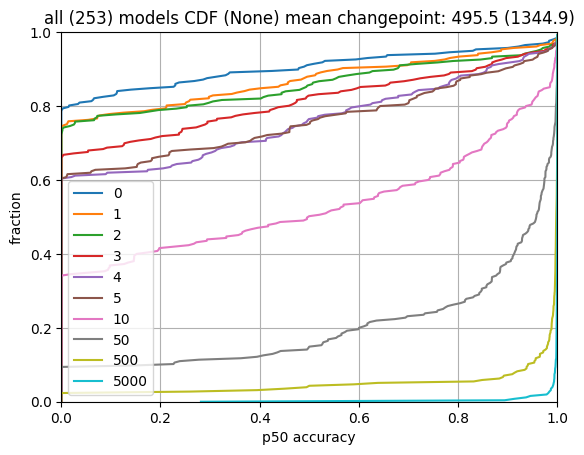

In [54]:
_ = plotCDF(max_changepoints=[5000], is_species=False, col="p50")

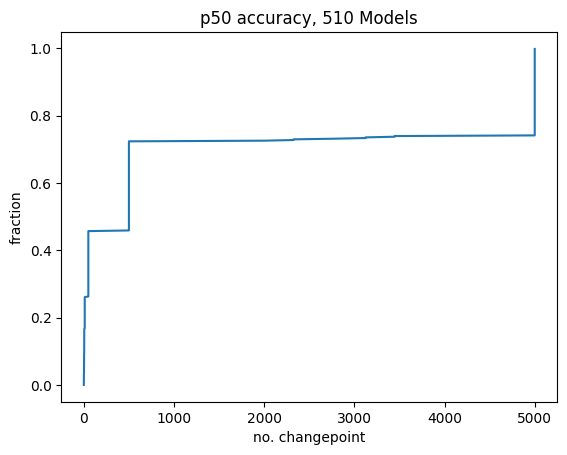

In [52]:
col = "p50"
df = DF [DF[cn.COL_AGGREGATION_TYPE] == "model"]
df = df[["num_changepoint", col]]
df = df.sort_values("num_changepoint")
dff = df [ df[col] >= 0.8 ]
yv = np.array(range(len(dff)))/len(dff)
plt.plot(dff["num_changepoint"], yv)
_ = plt.title(f"{col} accuracy, {len(dff)} Models")
plt.xlabel("no. changepoint")
_ = plt.ylabel("fraction")

In [ ]:
df

**Observations**
1. Increasing the number of changepoints increases accuracy up to about 20 changepoints.
2. There is decreasing benefit of increasing the number of changepoints. For example, going from 0 to 1 changepoint, increases the fraction of p10 = 0.8  by 5%, but there is almost no increase the this fraction by increasing from 10 changepoints to 20 changepoints.
3. About 40% of the species trajectories have a p10 accuracy of 0 even if changepoints are considered.
4. The benefit of increasing changepoints diminishes with the p10 accuracy.
5. For 10 changepoints, approximately 50% of species have a p10 accuracy of 0.8 and 45% a p10 accuracy of 0.9.

In [ ]:
_ = plotCDF(is_species = False, col="p50")

**Observations**
1. For 10 changepoints, approximately, 35% of models have a p10 accuracy of 0.8, and 30% of the models have a p10 accuracy of 0.9.
2. Accuracies for models are generally lower than those for species since a model combines many species and we are considering the tail of the distribution.
3. The other observations about species apply to models.

# Bad Biomodels

In [ ]:
dff = getSystemDF(DF)
sel = (dff["max_changepoint"] == 5000) & (dff["p50"] < 0.2)
dfff = dff[sel][["system_id", "p50"]]
dfff.sort_values("p50", ascending=False)

## Oscillating vs. Non-Oscillating Models

In [ ]:
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=False)
plt.figure()
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=True)

# Notes

1. Consider counting segments with accuracy at a desired level.
2. Some claims
    1. All the timecourses are smooth functions and so infinitesimal changes are well approximated by a linear function.
    1. A small fraction of models can be linearized with fewer than 10 changepoints
    2. A moderate number of models can be linearized with 50 changepoints out of 10K simulation points. These changepoints are isolated to key parts of the timecourses suggesting interesting transitions in the model.
    3. The number of accuracy of the piecewise linear approximation depends on both the number of changepoints and the number of simulation points. More simulation points provides better approximates the differentials. More changepoints, provides more adjustments to nonlinear elements in the model.
    4. Some parts of time course appear to be well approximated by a LODE but in fact are not.
    5. We can relate changes in fluxes in reactions with nonlinearities to the timecourse by where changepoints are positioned.